# *1. Load the libraries and dataset*

In [61]:
%%capture
!pip install textblob
!pip install wordcloud
!pip install nltk
import nltk
import re
import pandas as pd

In [7]:

df = pd.read_csv('data/BA_reviews.csv')  # Adjust path if needed
print(df.head())


   Unnamed: 0                                            reviews
0           0  ✅ Trip Verified |   Midday departure from Doha...
1           1  ✅ Trip Verified | I had a frustrating experien...
2           2  ✅ Trip Verified |   I flew business class with...
3           3  ✅ Trip Verified |   This was my first flight w...
4           4  ✅ Trip Verified |   I was travelling to Cochin...


# *2. Clean the reviews*

In [9]:
# Remove "✅ Trip Verified" and strip whitespace
df['reviews'] = df['reviews'].str.replace('✅ Trip Verified', '', regex=False).str.strip()


In [11]:
df.head()

,Unnamed: 0,reviews
0,0,| Midday departure from Doha is a very quiet...
1,1,| I had a frustrating experience with Qatar Ai...
2,2,| I flew business class with Qatar Airways o...
3,3,| This was my first flight with Qatar and I ...
4,4,| I was travelling to Cochin on Nov 21st 202...


In [19]:
# make lowercase
df['reviews'] = df['reviews'].str.lower()

# remove special character and digits
df['reviews'] = df['reviews'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

## Word count per review

We calculate the number of words in each review and plot it.

count    1000.000000
mean      115.815000
std        79.674819
min        17.000000
25%        59.750000
50%        93.000000
75%       150.000000
max       614.000000
Name: word_count, dtype: float64


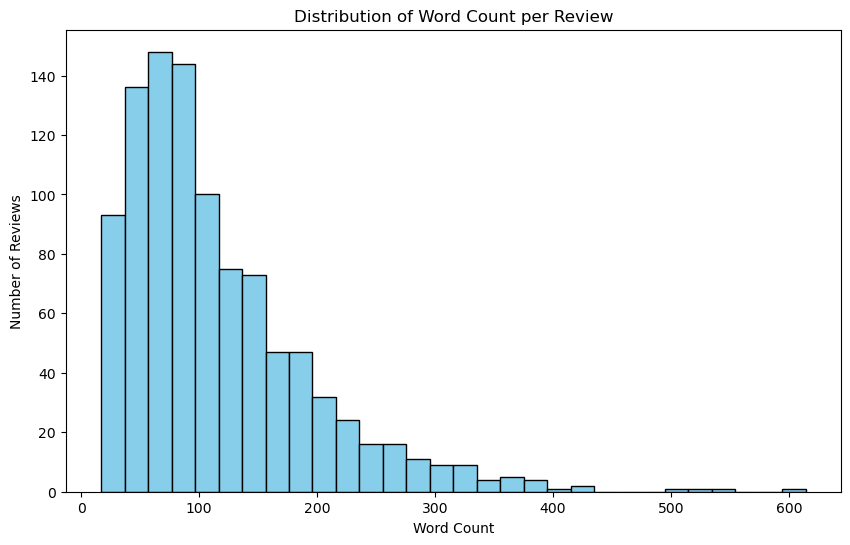

In [24]:
# Word count
df['word_count'] = df['reviews'].apply(lambda x: len(str(x).split()))

# Basic statistics
print(df['word_count'].describe())

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['word_count'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Word Count per Review')
plt.xlabel('Word Count')
plt.ylabel('Number of Reviews')
plt.show()

## Most common words
We find the most frequent words after removing stopwords.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dikhw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


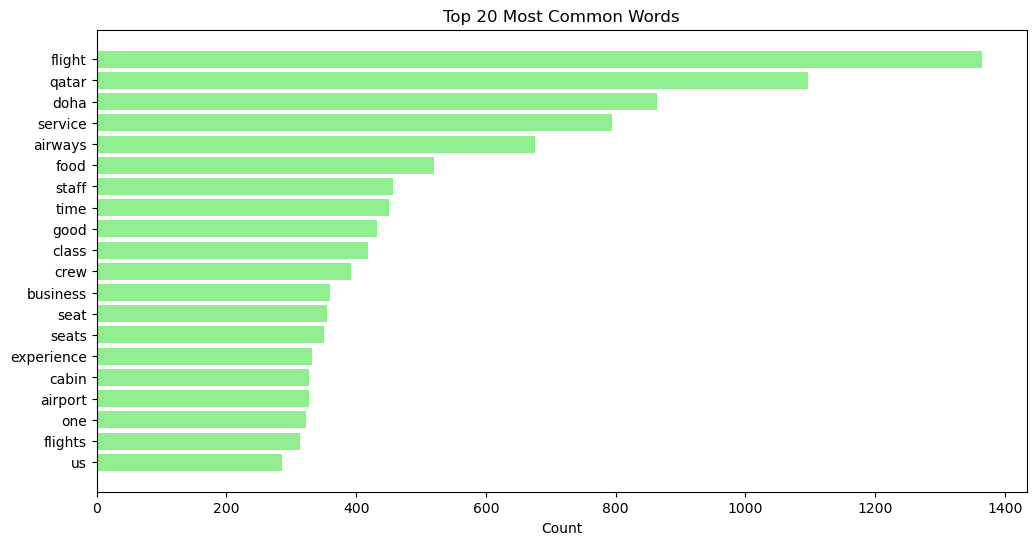

In [40]:

from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Remove stopwords
words = ' '.join(df['reviews'].dropna()).split()
filtered_words = [word for word in words if word.lower() not in stop_words]

# Count most common words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(20)

# Convert to DataFrame for plotting
common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])

# Visualization
plt.figure(figsize=(12,6))
plt.barh(common_words_df['word'], common_words_df['count'], color='lightgreen')
plt.title('Top 20 Most Common Words')
plt.gca().invert_yaxis()
plt.xlabel('Count')
plt.show()


## Sentiment analysis (positive/negative)
We'll use TextBlob to compute a sentiment polarity for each review.

C:\Users\dikhw\AppData\Local\Temp\ipykernel_14756\1395310837.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='pastel')


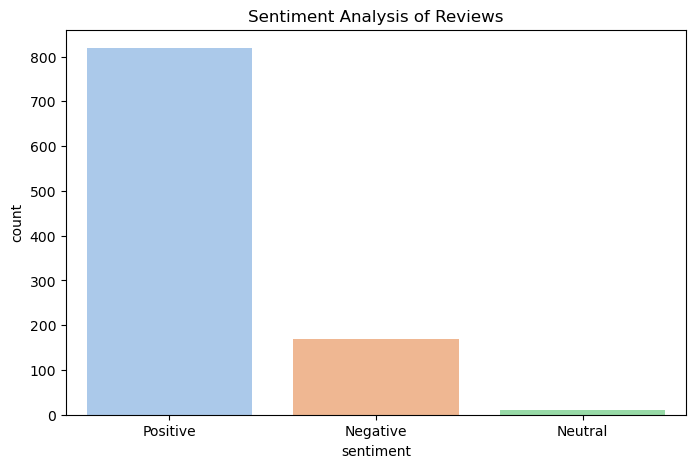

In [45]:
from textblob import TextBlob

# Sentiment polarity: -1 (negative) to 1 (positive)
df['polarity'] = df['reviews'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Label as Positive, Neutral, Negative
def get_sentiment(p):
    if p > 0:
        return 'Positive'
    elif p == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['polarity'].apply(get_sentiment)

# Count plot
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, palette='pastel')
plt.title('Sentiment Analysis of Reviews')
plt.show()

## Topic Modeling (optional, more advanced)
We'll do basic LDA Topic Modeling with sklearn.

In [102]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


# Vectorize
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
doc_term_matrix = vectorizer.fit_transform(df['reviews'].dropna())

# LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(doc_term_matrix)

# Store topics in a list
topics = []
for idx, topic in enumerate(lda.components_):
    top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    topics.append(top_words)

# Create DataFrame
topics_df = pd.DataFrame(topics, columns=[f'Word {i+1}' for i in range(10)])
topics_df.index = [f'Topic {i+1}' for i in range(len(topics))]

# Display the table
print(topics_df)


             Word 1   Word 2    Word 3   Word 4 Word 5   Word 6   Word 7  \
Topic 1       email  delayed     asked     hour  qatar  airport     told   
Topic 2    business     crew     class  airways   good     food     doha   
Topic 3      access     gate  aircraft    class    bus  service     time   
Topic 4  experience  airline      time  airport  staff     doha  service   
Topic 5        exit      row       did   booked   paid     doha    qatar   

          Word 8   Word 9 Word 10  
Topic 1     doha    hours  flight  
Topic 2  service    qatar  flight  
Topic 3     doha   flight  lounge  
Topic 4   flight  airways   qatar  
Topic 5   flight    seats    seat  


## WordCloud for each sentiment
You can create WordClouds for positive, neutral, and negative reviews separately!

In [79]:
# Create text for each sentiment
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['reviews'].dropna())
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['reviews'].dropna())
neutral_text  = ' '.join(df[df['sentiment'] == 'Neutral']['reviews'].dropna())


### WordCloud for Positive Reviews

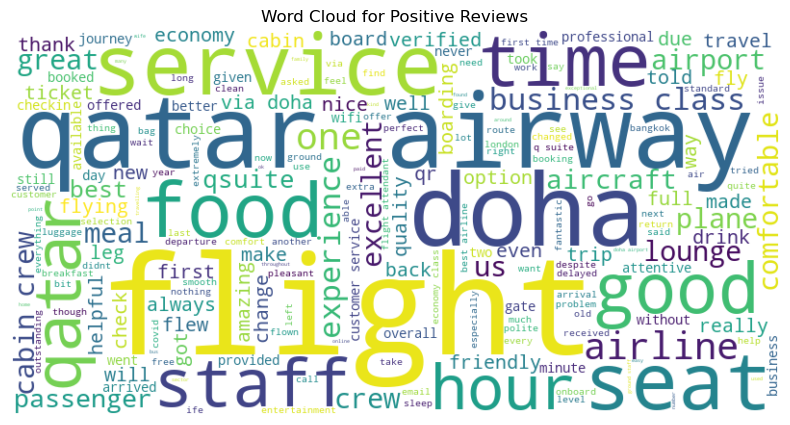

In [71]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = ' '.join(df[df['sentiment'] == 'Positive']['reviews'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()


### WordCloud for Negative Reviews

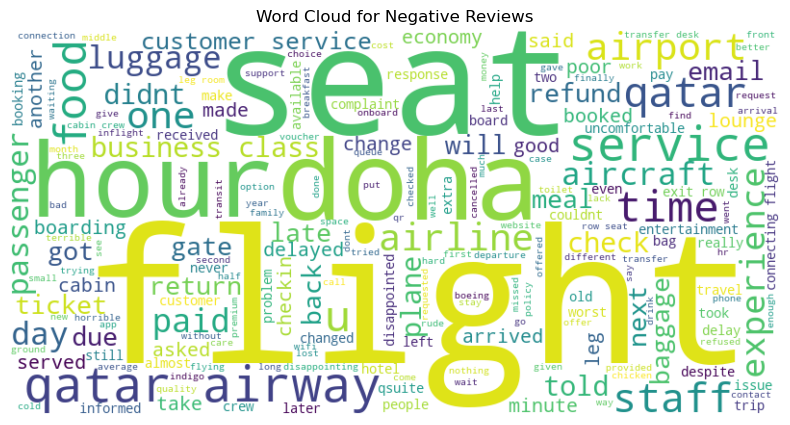

In [110]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negative_text = ' '.join(df[df['sentiment'] == 'Negative']['reviews'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()


### WordCloud for Neutral Reviews

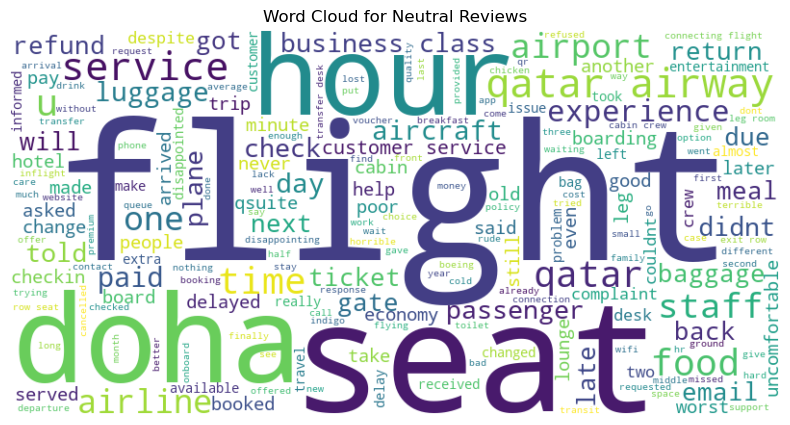

In [108]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

neutral_text = ' '.join(df[df['sentiment'] == 'Neutral']['reviews'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Neutral Reviews')
plt.show()
